## Contextualização da análise

Uma fintech deseja automatizar parte do processo de análise de crédito. A empresa possui uma base histórica com informações de clientes e os valores de empréstimos que foram concedidos. O objetivo é utilizar esses dados para construir um modelo de regressão capaz de estimar o valor de empréstimo que pode ser oferecido a um novo cliente.

## Etapa 1 – Carregando os dados

In [ ]:
import pandas as pd

df = pd.read_csv('/content/drive/MyDrive/Teste de Conhecimento - IA-AVP1/base_credito.csv')
display(df.head())

,idade,renda_mensal,score_credito,historico_pagamentos,valor_emprestimo
0,47,11522.48,634,76.73,35229.74
1,40,13157.86,589,90.83,44177.99
2,38,7296.76,721,77.94,33868.30
3,42,11193.87,710,94.09,52289.28
4,43,12798.60,576,73.83,38663.54


### Observação sobre a dimensão da base de dados

A base de dados `df` possui um total de **50.000 linhas**

## Etapa 2 – Conhecendo os dados

### Análise de Variáveis e Tipos de Dados

In [ ]:
# Exibir informações do DataFrame para verificar tipos de dados e valores não nulos
print("Informações do DataFrame:")
df.info()

print("\nEstatísticas Descritivas:")
display(df.describe())

Informações do DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 5 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   idade                 50000 non-null  int64  
 1   renda_mensal          50000 non-null  float64
 2   score_credito         50000 non-null  int64  
 3   historico_pagamentos  50000 non-null  float64
 4   valor_emprestimo      50000 non-null  float64
dtypes: float64(3), int64(2)
memory usage: 1.9 MB

Estatísticas Descritivas:


,idade,renda_mensal,score_credito,historico_pagamentos,valor_emprestimo
count,50000.00000,50000.000000,50000.000000,50000.000000,50000.000000
mean,40.08028,7542.184144,649.581780,81.836888,31736.158491
std,10.77612,4524.255313,84.648363,11.209708,14456.325322
min,18.00000,1500.000000,300.000000,16.210000,1000.000000
25%,33.00000,4463.347500,592.000000,75.160000,22018.212500
50%,40.00000,6452.295000,650.000000,83.720000,29039.420000
75%,47.00000,9395.700000,707.000000,90.330000,38275.932500
max,70.00000,50000.000000,850.000000,100.000000,150000.000000


### Explicação das Variáveis:

**Variáveis de Entrada (Features):**

*   **idade:** Idade do cliente. (Tipo: `int64`)
*   **renda_mensal:** Renda mensal do cliente. (Tipo: `float64`)
*   **score_credito:** Pontuação de crédito do cliente, indicando sua capacidade de pagamento. (Tipo: `int64`)
*   **historico_pagamentos:** Histórico de pagamentos do cliente, representando a quantidade de pagamentos em dia (0 a 100, em porcentagem). (Tipo: `float64`)

**Variável alvo:**

*   **valor_emprestimo:** O valor do empréstimo que foi concedido, e é a variável que o modelo de regressão deverá prever. (Tipo: `float64`)

## Etapa 3 – Analisando os dados

### Análise da Relação entre Renda Mensal e Valor do Empréstimo

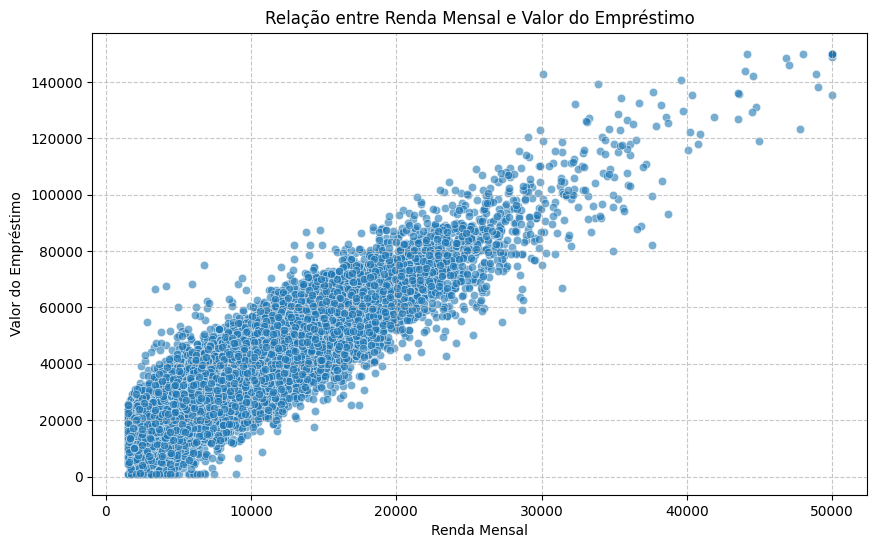

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.scatterplot(x='renda_mensal', y='valor_emprestimo', data=df, alpha=0.6)
plt.title('Relação entre Renda Mensal e Valor do Empréstimo')
plt.xlabel('Renda Mensal')
plt.ylabel('Valor do Empréstimo')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

### Comportamento Observado:

O gráfico de dispersão sugere uma relação positiva entre **renda_mensal** e **valor_emprestimo**. De modo geral, à medida que a renda mensal aumenta, o valor do empréstimo também tende a aumentar. Também é possível observar maior dispersão dos valores de empréstimo nas faixas de renda mais altas, indicando maior variabilidade nesses valores.

## Etapa 4 – Preparando os dados

### Separação dos Dados em Conjunto de Treinamento e Teste

Nesta etapa, dividiremos o nosso conjunto de dados em dois subconjuntos:

*   **Conjunto de Treinamento (70%):** Utilizado para treinar o modelo de regressão, aprendendo os padrões e relações entre as variáveis.
*   **Conjunto de Teste (30%):** Utilizado para avaliar o desempenho do modelo em dados que ele nunca viu antes, garantindo que o modelo generalize bem para novos dados.

Utilizaremos `random_state` para garantir a reprodutibilidade da divisão.

In [ ]:
from sklearn.model_selection import train_test_split

# Separar variáveis de entrada (features) e variável alvo (target)
X = df.drop('valor_emprestimo', axis=1)
y = df['valor_emprestimo']

# Dividir os dados em conjuntos de treinamento e teste (70% treinamento, 30% teste)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Exibir as dimensões dos conjuntos resultantes
print(f'Shape do conjunto de treinamento (features): {X_train.shape}')
print(f'Shape do conjunto de teste (features): {X_test.shape}')
print(f'Shape do conjunto de treinamento (target): {y_train.shape}')
print(f'Shape do conjunto de teste (target): {y_test.shape}')

Shape do conjunto de treinamento (features): (35000, 4)
Shape do conjunto de teste (features): (15000, 4)
Shape do conjunto de treinamento (target): (35000,)
Shape do conjunto de teste (target): (15000,)


## Etapa 5 – Treinando o modelo

### Construção e Treinamento do Modelo de Regressão Linear

Para esta tarefa, utilizaremos um modelo de Regressão Linear, que é um algoritmo fundamental e de fácil interpretação para prever uma variável alvo contínua. Ele busca encontrar a relação linear que melhor se ajusta aos dados.

Os passos serão:
1.  **Criação do Modelo:** Instanciar o `LinearRegression`.
2.  **Treinamento:** Ajustar o modelo aos dados de treinamento (`X_train`, `y_train`).
3.  **Previsões:** Gerar previsões para o conjunto de teste (`X_test`).

In [ ]:
from sklearn.linear_model import LinearRegression

try:
    # 1. Criar o modelo
    model = LinearRegression()

    # 2. Treinar o modelo
    model.fit(X_train, y_train)

    print("Modelo de Regressão Linear treinado com sucesso!")

    # 3. Gerar previsões
    y_pred = model.predict(X_test)

    print("Previsões geradas para o conjunto de teste.")

except Exception as erro:
    print("Ocorreu um erro durante o treinamento ou a previsão.")
    print("Detalhes do erro:", erro)

Modelo de Regressão Linear treinado com sucesso!
Previsões geradas para o conjunto de teste.


## Etapa 6 – Avaliando o Modelo

### Avaliação do Desempenho do Modelo de Regressão Linear

Após treinar o modelo e gerar as previsões, é crucial avaliar o quão bem ele está se saindo. Utilizaremos as seguintes métricas para quantificar o desempenho do nosso modelo de Regressão Linear:

*   **Erro Absoluto Médio (MAE - Mean Absolute Error):** Representa a média das diferenças absolutas entre os valores previstos e os valores reais. É uma métrica simples e interpretável, indicando a magnitude média dos erros do modelo.
*   **Erro Quadrático Médio (MSE - Mean Squared Error):** Calcula a média dos quadrados das diferenças entre os valores previstos e os valores reais. Penaliza erros maiores de forma mais significativa, sendo útil para destacar a presença de grandes desvios.

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# Calcular o Erro Absoluto Médio (MAE)
mae = mean_absolute_error(y_test, y_pred)
print(f'Erro Absoluto Médio (MAE): {mae:.2f}')

# Calcular o Erro Quadrático Médio (MSE)
mse = mean_squared_error(y_test, y_pred)
print(f'Erro Quadrático Médio (MSE): {mse:.2f}')

Erro Absoluto Médio (MAE): 3001.04
Erro Quadrático Médio (MSE): 16045712.28


### Interpretação das Métricas de Avaliação

Com base nos valores calculados:

*   **MAE (Erro Absoluto Médio):** Um MAE de `3001.04` significa que, em média, as previsões do nosso modelo estão a `3001.04` unidades de diferença dos valores reais do `valor_emprestimo`. Quanto menor o MAE, melhor o modelo.

*   **MSE (Erro Quadrático Médio):** O MSE de `16045712.28` representa a média dos erros quadráticos. Como ele penaliza mais os erros grandes, um valor elevado pode indicar a presença de previsões com desvios consideráveis.

## Etapa 7 – Comparação de valores reais e previstos

### Comparação Visual e Quantitativa dos Valores Reais e Previstos

In [ ]:
# Criar um DataFrame para comparar os valores reais (y_test) e os previstos (y_pred)
comparison_df = pd.DataFrame({'Valor Real': y_test, 'Valor Previsto': y_pred})

# Exibir as primeiras 10 linhas para uma visualização rápida
print("Comparação dos Valores Reais e Previstos (primeiras 10 linhas):")
display(comparison_df.head(10))

Comparação dos Valores Reais e Previstos (primeiras 10 linhas):


,Valor Real,Valor Previsto
33553,22268.46,14795.304141
9427,27457.59,29514.265230
199,25451.04,25806.438027
12447,23890.67,21081.147964
39489,27754.95,27899.326404
42724,12544.92,14506.091353
10822,28759.01,27409.433130
49498,46454.49,41005.125572
4144,43199.01,36523.077074
36958,34051.39,35761.144897


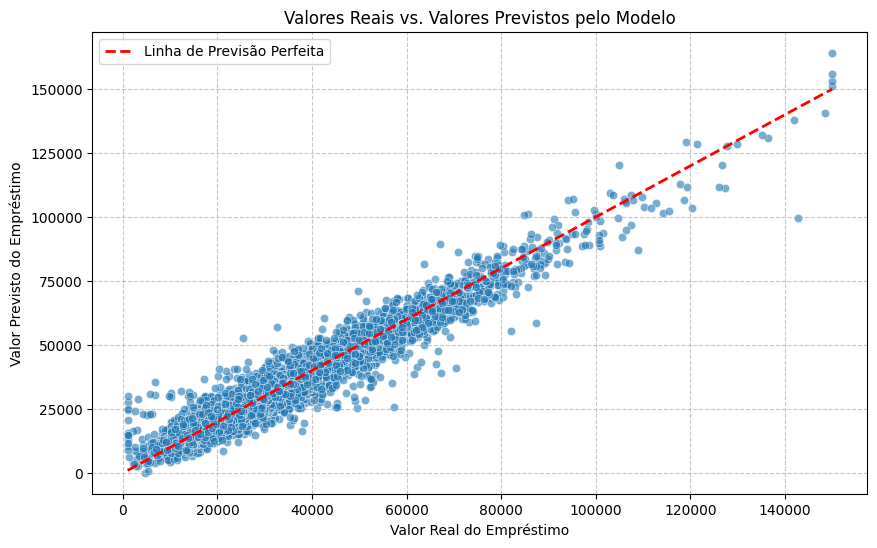

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plotar os valores reais vs. previstos
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Valor Real', y='Valor Previsto', data=comparison_df, alpha=0.6)
plt.title('Valores Reais vs. Valores Previstos pelo Modelo')
plt.xlabel('Valor Real do Empréstimo')
plt.ylabel('Valor Previsto do Empréstimo')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linestyle='--', lw=2, label='Linha de Previsão Perfeita')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.show()

### Análise da Comparação

Observando a tabela e o gráfico de dispersão:

*   A **tabela** mostra exemplos claros de como as previsões do modelo se comparam aos valores reais. Podemos ver que, para alguns casos, as previsões estão muito próximas dos valores reais, enquanto em outros há uma diferença maior.

*   O **gráfico de dispersão** apresenta os valores reais no eixo X e os valores previstos no eixo Y. A linha tracejada vermelha representa a 'linha de previsão perfeita' (onde `Valor Real = Valor Previsto`). Quanto mais próximos os pontos azuis estiverem dessa linha, melhor o desempenho do modelo.

    De modo geral, os pontos estão relativamente alinhados com a linha de previsão perfeita, indicando que o modelo consegue acompanhar a tendência geral dos valores de empréstimo. Entretanto, a dispersão dos pontos em torno da linha mostra que existem diferenças entre alguns valores reais e previstos, o que também é observado pelos valores de MAE e MSE calculados anteriormente.

## Etapa 8 – Fazer uma previsão

### Previsão para um Novo Cliente

Nesta etapa, vamos simular a previsão do valor de empréstimo para um novo cliente. Para isso, definiremos características hipotéticas para este cliente e utilizaremos o modelo de Regressão Linear treinado para gerar a previsão.

In [ ]:
import pandas as pd

# 1. Definir as características de um novo cliente
novo_cliente_data = {
    'idade': [35],  # Idade do cliente
    'renda_mensal': [7500.00],  # Renda mensal do cliente
    'score_credito': [720],  # Pontuação de crédito
    'historico_pagamentos': [90.5]  # Histórico de pagamentos (em porcentagem)
}

novo_cliente_df = pd.DataFrame(novo_cliente_data)

print("Características do Novo Cliente:")
display(novo_cliente_df)

# 2. Fazer a previsão usando o modelo treinado
valor_emprestimo_previsto = model.predict(novo_cliente_df)

# 3. Apresentar o valor previsto
print(f"\nO valor de empréstimo previsto para este novo cliente é: R$ {valor_emprestimo_previsto[0]:.2f}")

Características do Novo Cliente:


,idade,renda_mensal,score_credito,historico_pagamentos
0,35,7500.0,720,90.5



O valor de empréstimo previsto para este novo cliente é: R$ 36468.79


### Interpretação do Resultado

Para o cliente hipotético com as características definidas:

*   **Idade:** 35 anos
*   **Renda Mensal:** R$ 7.500,00
*   **Score de Crédito:** 720
*   **Histórico de Pagamentos:** 90.5%

O modelo de Regressão Linear previu um valor de empréstimo de **R$ 36.468,79**.

Essa previsão serve como uma estimativa inicial que a fintech pode usar para agilizar o processo de análise de crédito. É importante lembrar que esta é uma previsão baseada nos dados históricos e no modelo treinado. Na prática, outros fatores e políticas internas da empresa podem influenciar a decisão final de concessão e o valor real do empréstimo.

## Etapa 9 – Conclusão
O modelo de regressão apresentou resultados adequados para estimar o valor dos empréstimos? Quais são suas principais limitações?

**Análise Final do Modelo de Regressão**

O modelo de Regressão Linear apresentou resultados razoavelmente adequados para estimar o valor dos empréstimos no conjunto de dados utilizado. O MAE foi de R\$ 3.001,04, indicando que, em média, as previsões diferiram dos valores reais em aproximadamente R\$ 3.000.. O gráfico de valores reais e previstos também mostrou um alinhamento geral entre as previsões e os valores reais, embora existam diferenças maiores em alguns casos.

O modelo possui limitações. Por ser uma Regressão Linear, ele busca representar relações lineares entre as características utilizadas e o valor do empréstimo, podendo não representar completamente relações mais complexas presentes nos dados. Além disso, o MSE de 16.045.712,28 atribui maior peso aos erros maiores, indicando que algumas previsões apresentam diferenças mais significativas.

Outra limitação está relacionada aos próprios dados históricos utilizados no treinamento. Caso eles não sejam representativos de novos clientes, as previsões podem não apresentar o mesmo comportamento. Portanto, o modelo fornece estimativas e seus resultados devem ser interpretados considerando as características e limitações do conjunto de dados utilizado.